<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [1]:
# Import torch
import torch

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors. 
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [2]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

n_samples = 1000
noise = 0.03
shuffle = True

X,y = make_moons(n_samples=n_samples,
                 shuffle=shuffle,
                 noise=noise,
                 random_state=RANDOM_SEED)

X.shape, y.shape

((1000, 2), (1000,))

In [3]:
# len(X[:,0]), len(X[:,1]), len(y)
print(f"First 5 values of X[:5,0]:\n{X[:5,0]}")
print(f"First 5 values of X[:5,1]:\n{X[:5,1]}")
print(f"First 5 labels of y: {y[:5]}")



First 5 values of X[:5,0]:
[-0.00933187  0.95457387  0.9185256   0.41276802 -0.84532016]
First 5 values of X[:5,1]:
[ 0.39098105 -0.47375583 -0.42519648 -0.37638459  0.52879908]
First 5 labels of y: [1 1 1 1 0]


In [4]:
# Turn data into a DataFrame
import pandas as pd
df = pd.DataFrame({"X1":X[:,0],
                   "X2":X[:,1],
                   "labels":y})
df.head()

,X1,X2,labels
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0


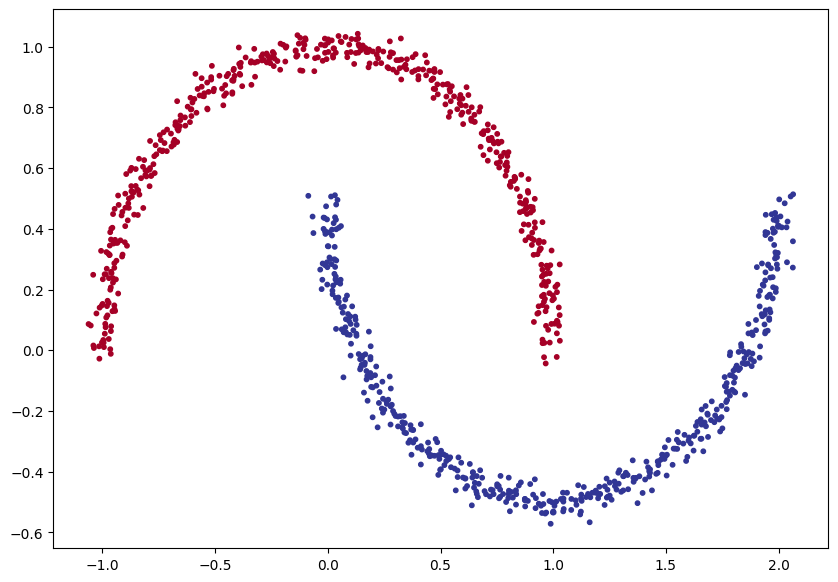

In [5]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.scatter(X[:,0],X[:,1], c=y, cmap=plt.cm.RdYlBu, s=10)
plt.show()

In [6]:
# Turn data into tensors of dtype float
# X = torch.tensor(X,dtype=torch.float)
# y = torch.tensor(y, dtype = torch.float)

# Above method works well but it is not optimal and is more memory intensive.
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()

# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=RANDOM_SEED, test_size=0.2)
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)


X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [12]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    ## Your code here ##
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()

        self.layers_stack = nn.Sequential(
            nn.Linear(
                    in_features=input_shape,
                    out_features=hidden_units
                    ),
            nn.ReLU(),
            nn.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units
                    ),
            nn.ReLU(),
            nn.Linear(
                    in_features=hidden_units,
                    out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor)-> torch.Tensor:
        x = self.layers_stack(x)
        return x

# Instantiate the model
## Your code here ##
torch.manual_seed(42)
model_0 = MoonModelV0(
    input_shape=2,
    hidden_units=10,
    output_shape=1
).to(device)

model_0.state_dict()

OrderedDict([('layers_stack.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layers_stack.0.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layers_stack.2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                 

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [13]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()

# Import accuracy_fn from helper function
from helper_function import accuracy_fn

# Setup optimizer to optimize model's parameters
optimizer = torch.optim.SGD(params = model_0.parameters(), lr =0.1)

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [33]:
# What's coming out of our model?

# logits (raw outputs of model)
print("Logits:")
## Your code here ##
print("Raw output. They are used to calculate loss like CrossEntropyLoss, BCEWithLogitsLoss, etc. They are output which is not gone thorugh activation functions like Sigmoid or softmax.")

# Prediction probabilities
print("Pred probs:")
## Your code here ##
print("Prediction probability means Logits are passed to the activation function the output is prediction probability. Further prediction probability is used to predict labels.")

# Prediction labels
print("Pred labels:")
## Your code here ##
print("Prediction labels: They are ground truth. For Binary classification the values are 0,1. For multi-class classification values can be 0,1,2,...")

Logits:
Raw output. They are used to calculate loss like CrossEntropyLoss, BCEWithLogitsLoss, etc. They are output which is not gone thorugh activation functions like Sigmoid or softmax.
Pred probs:
Prediction probability means Logits are passed to the activation function the output is prediction probability. Further prediction probability is used to predict labels.
Pred labels:
Prediction labels: They are ground truth. For Binary classification the values are 0,1. For multi-class classification values can be 0,1,2,...


In [32]:
torch.manual_seed(42)

epochs = 400

for epoch in range(epochs):
    ## train
    model_0.train()

    # forward pass
    y_logits = model_0(X_train).squeeze() # shape is [800,1] -> squeeze garera [800,] banaune
    y_preds = torch.round(torch.sigmoid(y_logits)) # mathi bata aako value lai sigmoid function ma haleko. then round garda feri ki ta 1 or 0 ko value linxa. Sigmoid never gives off value as 0 or 1. Its probabilistic. So, rounding helps here.

    # Calculate loss
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true= y_train, y_pred= y_preds)

    # Optimizer zero grad
    optimizer.zero_grad()

    # loss backward
    loss.backward()

    # Optimizer step()- Gradient Descent
    optimizer.step()

    ## Testing
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true = y_test, y_pred = test_preds)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}  loss: {loss:.4f}    acc: {acc:.3f} %   test loss: {test_loss:.4f}  test_acc: {test_acc:.3f} %")

Epoch: 0  loss: 0.1908    acc: 91.375 %   test loss: 0.1853  test_acc: 92.500 %
Epoch: 10  loss: 0.1872    acc: 91.500 %   test loss: 0.1815  test_acc: 93.000 %
Epoch: 20  loss: 0.1836    acc: 91.625 %   test loss: 0.1776  test_acc: 93.000 %
Epoch: 30  loss: 0.1798    acc: 92.000 %   test loss: 0.1737  test_acc: 93.000 %
Epoch: 40  loss: 0.1760    acc: 92.250 %   test loss: 0.1698  test_acc: 93.000 %
Epoch: 50  loss: 0.1722    acc: 92.500 %   test loss: 0.1658  test_acc: 93.000 %
Epoch: 60  loss: 0.1682    acc: 92.625 %   test loss: 0.1616  test_acc: 93.000 %
Epoch: 70  loss: 0.1642    acc: 92.750 %   test loss: 0.1575  test_acc: 93.500 %
Epoch: 80  loss: 0.1600    acc: 93.125 %   test loss: 0.1532  test_acc: 93.500 %
Epoch: 90  loss: 0.1558    acc: 93.375 %   test loss: 0.1489  test_acc: 93.500 %
Epoch: 100  loss: 0.1515    acc: 93.750 %   test loss: 0.1445  test_acc: 94.000 %
Epoch: 110  loss: 0.1471    acc: 94.375 %   test loss: 0.1400  test_acc: 94.500 %
Epoch: 120  loss: 0.1426   

In [16]:
y_preds.shape, y_train.shape

(torch.Size([800]), torch.Size([800]))

In [18]:
## TODO: Uncomment this to set the seed
# torch.manual_seed(RANDOM_SEED)

# Setup epochs


# Send data to the device


# Loop through the data
# for epoch in range(epochs):
  ### Training
  

  # 1. Forward pass (logits output)
  
  # Turn logits into prediction probabilities
  

  # Turn prediction probabilities into prediction labels
  

  # 2. Calculaute the loss
  # loss = loss_fn(y_logits, y_train) # loss = compare model raw outputs to desired model outputs

  # Calculate the accuracy
  # acc = acc_fn(y_pred, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  

  # 4. Loss backward (perform backpropagation) - https://brilliant.org/wiki/backpropagation/#:~:text=Backpropagation%2C%20short%20for%20%22backward%20propagation,to%20the%20neural%20network's%20weights.
  
  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression) 
  

  ### Testing
  # model_0.eval() 
  # with torch.inference_mode():
    # 1. Forward pass (to get the logits)
    
    # Turn the test logits into prediction labels
    

    # 2. Caculate the test loss/acc
    

  # Print out what's happening every 100 epochs
  # if epoch % 100 == 0:
    

## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [34]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

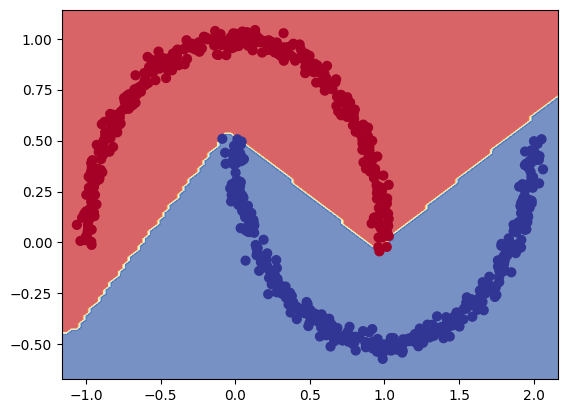

In [37]:
# Plot decision boundaries for training and test sets
plot_decision_boundary(model= model_0,
                       X=X_train,
                       y= y_train,)


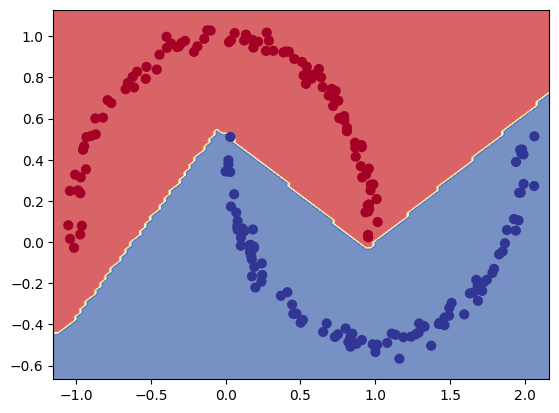

In [38]:
plot_decision_boundary(model= model_0,
                       X=X_test,
                       y= y_test)

## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

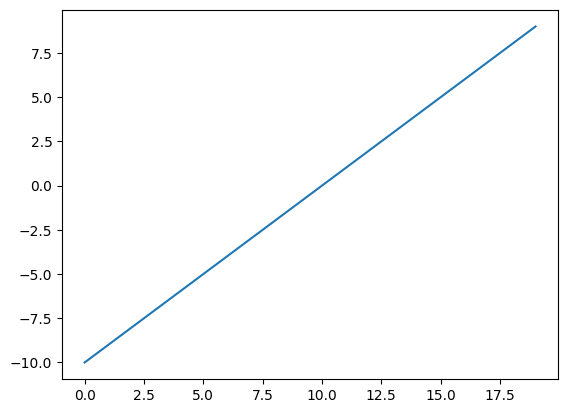

In [42]:
# Create a straight line tensor
p = torch.arange(-10,10)

plt.plot(p)

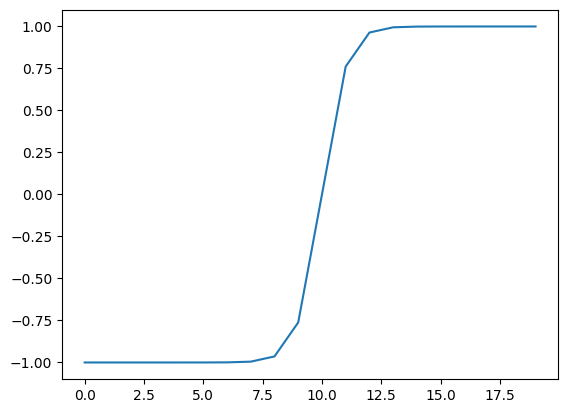

In [43]:
# Test torch.tanh() on the tensor and plot it
plt.plot(torch.tanh(p))

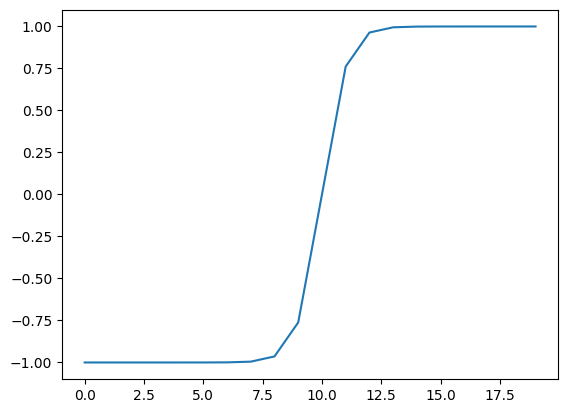

In [44]:
# Replicate torch.tanh() and plot it

#tanh = e^z - e^-x / e^z + e^-x
def tanh_fn(x):
    return (torch.exp(x)-torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(tanh_fn(p))

## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

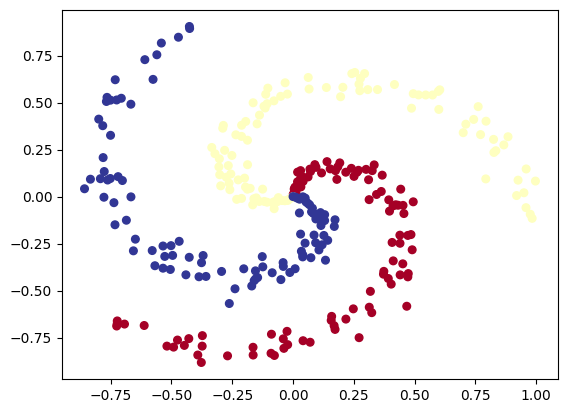

In [ ]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.RdYlBu)
plt.show()

In [55]:
X.shape, y.shape, X.dtype, y.dtype

((300, 2), (300,), dtype('float64'), dtype('uint8'))

In [61]:
# Turn data into tensors
# X = torch.from_numpy(X).type(torch.float).to(device)  # features as float32
# y = torch.from_numpy(y).type(torch.LongTensor).to(device)  # labels need to be of type long

# Convert to tensor if needed and ensure correct dtype
X = torch.as_tensor(X, dtype=torch.float32).to(device)
y = torch.as_tensor(y, dtype=torch.long).to(device)

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Send data to device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

# Print shapes to verify
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: torch.Size([240, 2]), y_train shape: torch.Size([240])
X_test shape: torch.Size([60, 2]), y_test shape: torch.Size([60])


In [66]:
# Let's calculate the accuracy for when we fit our model
from torchmetrics import Accuracy

# Create accuracy function for multi-class data
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device)


In [77]:
# Prepare device agnostic code
# device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class SpiralModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()

        self.layers_stack = nn.Sequential(
            nn.Linear(
                    in_features=input_shape,
                    out_features=hidden_units
                    ),
            nn.ReLU(),
            nn.Linear(
                    in_features=hidden_units,
                    out_features=hidden_units
                    ),
            nn.ReLU(),
            nn.Linear(
                    in_features=hidden_units,
                    out_features=output_shape
            )
        )

    def forward(self, x: torch.Tensor)-> torch.Tensor:
        x = self.layers_stack(x)
        return x


# Instantiate model and send it to device
model_1 = SpiralModelV0(input_shape=2, hidden_units=10, output_shape=3).to(device)
model_1, model_1.state_dict()

(SpiralModelV0(
   (layers_stack): Sequential(
     (0): Linear(in_features=2, out_features=10, bias=True)
     (1): ReLU()
     (2): Linear(in_features=10, out_features=10, bias=True)
     (3): ReLU()
     (4): Linear(in_features=10, out_features=3, bias=True)
   )
 ),
 OrderedDict([('layers_stack.0.weight',
               tensor([[-0.0238, -0.0822],
                       [ 0.4423, -0.0654],
                       [ 0.4435,  0.5112],
                       [-0.6139,  0.2721],
                       [ 0.1335,  0.1520],
                       [ 0.1032,  0.1934],
                       [-0.3402, -0.0905],
                       [ 0.6718,  0.4751],
                       [-0.0266, -0.6651],
                       [ 0.0310, -0.4815]], device='cuda:0')),
              ('layers_stack.0.bias',
               tensor([ 0.5750, -0.4293, -0.0511, -0.1569,  0.1258,  0.6654,  0.0672,  0.4095,
                        0.5489,  0.5709], device='cuda:0')),
              ('layers_stack.2.weight',
     

In [78]:
# Setup data to be device agnostic

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
## Your code here ##

print("Pred probs:")
## Your code here ##

print("Pred labels:")
## Your code here ##

Logits:
Pred probs:
Pred labels:


In [79]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [82]:
# Build a training loop for the model
epochs = 1000
# Loop over data
for epoch in range(epochs):

  ## Training
  model_1.train()
  # 1. Forward pass
  y_logits = model_1(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_logits, y_train)  # Fixed: pass logits and true labels
  
  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(X_test)
    # 2. Calculate loss and acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_logits, y_test)  # Fixed: pass logits and true labels
  
  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch}  loss: {loss:.4f}  acc: {acc*100:.3f} %  test loss: {test_loss:.4f}  test acc: {test_acc*100:.3f} %")

Epoch: 0  loss: 0.2696  acc: 89.167 %  test loss: 0.2501  test acc: 90.000 %
Epoch: 100  loss: 0.2404  acc: 91.667 %  test loss: 0.2269  test acc: 90.000 %
Epoch: 200  loss: 0.2197  acc: 92.500 %  test loss: 0.2023  test acc: 91.667 %
Epoch: 300  loss: 0.2002  acc: 92.917 %  test loss: 0.1755  test acc: 95.000 %
Epoch: 400  loss: 0.1765  acc: 93.333 %  test loss: 0.1467  test acc: 95.000 %
Epoch: 500  loss: 0.1457  acc: 95.000 %  test loss: 0.1141  test acc: 96.667 %
Epoch: 600  loss: 0.1234  acc: 96.250 %  test loss: 0.0933  test acc: 98.333 %
Epoch: 700  loss: 0.1055  acc: 96.667 %  test loss: 0.0771  test acc: 100.000 %
Epoch: 800  loss: 0.0948  acc: 97.500 %  test loss: 0.0663  test acc: 100.000 %
Epoch: 900  loss: 0.0869  acc: 97.917 %  test loss: 0.0580  test acc: 100.000 %


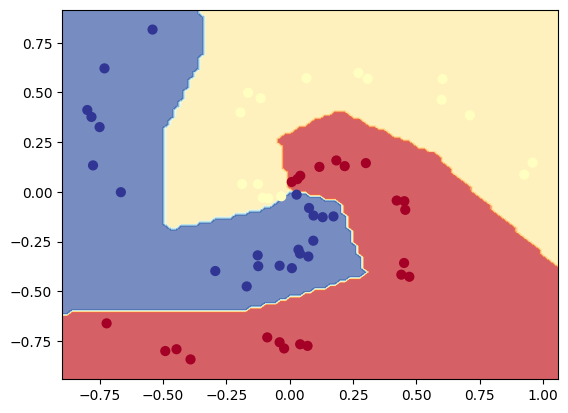

In [83]:
# Plot decision boundaries for training and test sets
plot_decision_boundary(model_1,X_test,y_test)

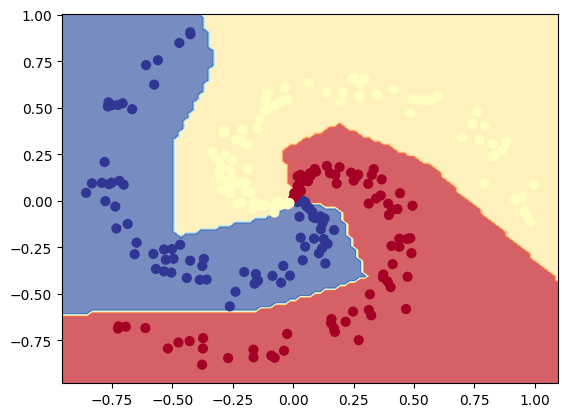

In [84]:
# Plot decision boundaries for training and test sets
plot_decision_boundary(model_1,X_train,y_train)